In [23]:
import os
import urllib.request
import tarfile
import shutil

# Define the paths
url = "https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
tar_path = "pbmc3k_filtered_gene_bc_matrices.tar.gz"
extract_path = "./filtered_gene_bc_matrices"
final_dir = "./data/hg19"

# 1. Download the dataset natively in Python
if not os.path.exists(tar_path):
    print("Downloading 10x Genomics dataset...")
    urllib.request.urlretrieve(url, tar_path)
    print("Download complete.")

# 2. Extract the archive
if not os.path.exists(extract_path) and not os.path.exists(final_dir):
    print("Extracting files...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete.")

# 3. Move into the expected directory structure
os.makedirs("./data", exist_ok=True)
if not os.path.exists(final_dir):
    print("Moving files to ./data/hg19...")
    shutil.move(f"{extract_path}/hg19", final_dir)
    print("Reproducible setup complete.")
else:
    print("Data directory already configured. Ready to load matrix.")

Data directory already configured. Ready to load matrix.


In [29]:
import os 
import numpy as np 
import pandas as pd 
import scipy.io 
import matplotlib.pyplot as plt 

# 1.load the dataset 
# Make sure all files are under 'data' directory 
data_path = "./data/hg19" 
matrix_file = os.path.join(data_path, "matrix.mtx") 
genes_file = os.path.join(data_path, "genes.tsv")
barcodes_file = os.path.join(data_path, "barcodes.tsv") 

print("Loading raw 10x Genomics sparse matrix")
# Load and transpose, Rows = Cells, Columns= Genes
X_raw = scipy.io.mmread(matrix_file).T.tocsr()

# Load metadata 
genes= pd.read_csv(genes_file, header=None, sep='\t').iloc[:, 1].values
barcodes = pd.read_csv(barcodes_file, header=None, sep='\t').iloc[:,0].values

print(f"Dataset Loaded Successfully: {X_raw.shape[0]} cells and {X_raw.shape[1]} genes.") 

Loading raw 10x Genomics sparse matrix
Dataset Loaded Successfully: 2700 cells and 32738 genes.


In [31]:
# 2. Calculating Summary Statistics 
# Calculate cell-level metrics from scratch 
library_size = np.array(X_raw.sum(axis=1)).flatten()
n_genes = np.array((X_raw >0).sum(axis=1)).flatten()

# Calculate Mitochonrial Percentage 
mito_indices = [i for i, gene in enumerate(genes) if gene.startswith("MT-")]
if len(mito_indices) > 0: 
    mito_counts = np.array(X_raw[:, mito_indices].sum(axis=1)).flatten()
    percent_mito = (mito_counts /library_size) * 100
else: 
    percent_mito = np.zeros(len(library_size)) 
# Print Summary Statistics 
print("--- Preliminary Summary Statistics ---") 
print(f"Mean library size (read per cell): {np.mean(library_size):.2f}")
print(f"Median genes detected per cell: {np.median(n_genes):.0f}")
print(f"Max mitochondrial percentage found: {np.max(percent_mito):.2f}%") 

--- Preliminary Summary Statistics ---
Mean library size (read per cell): 2366.90
Median genes detected per cell: 817
Max mitochondrial percentage found: 22.57%


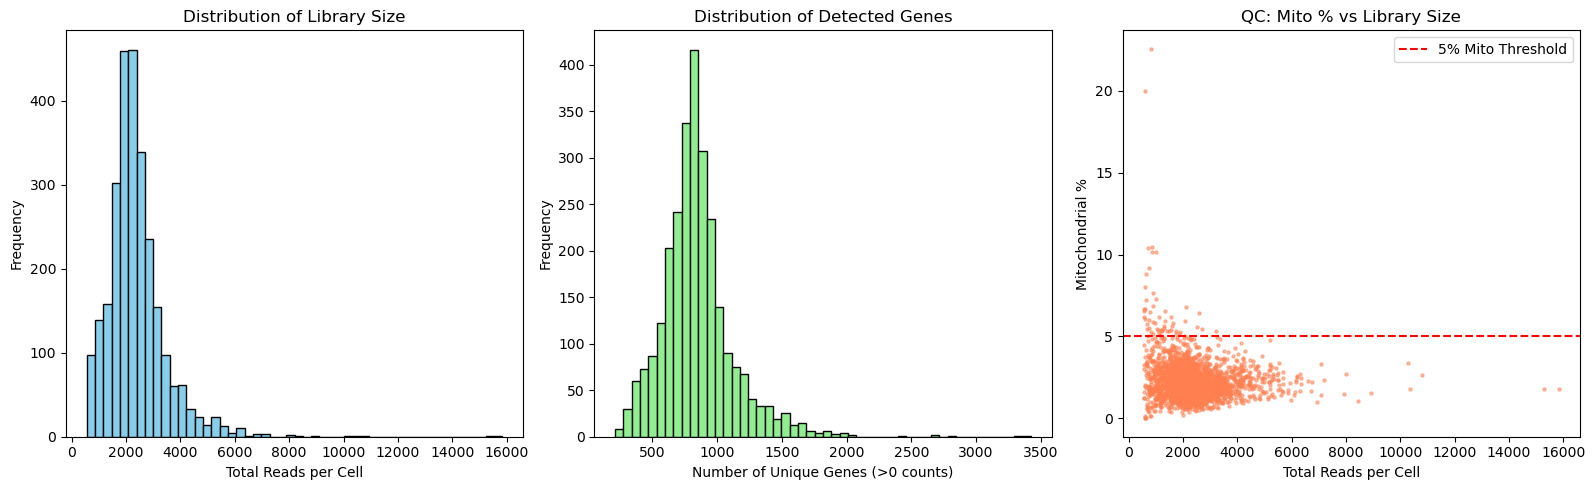

In [9]:
# 3. Data Visualization 
# Generate 3 distinct visualization for Quality Control 
fig, axs = plt.subplots(1,3, figsize=(16,5))

# Visualization 1: Histogram of library Size 
axs[0].hist(library_size, bins=50, color='skyblue', edgecolor='black')
axs[0].set_title('Distribution of Library Size') 
axs[0].set_xlabel('Total Reads per Cell')
axs[0].set_ylabel('Frequency')

# Visualization 2: Histogram of Detected Genes
axs[1].hist(n_genes, bins=50, color='lightgreen', edgecolor='black')
axs[1].set_title('Distribution of Detected Genes')
axs[1].set_xlabel('Number of Unique Genes (>0 counts)')
axs[1].set_ylabel('Frequency')

# Visualization 3: Scatter Plot (Classic Single-Cell QC) 
axs[2].scatter(library_size, percent_mito, alpha=0.5, s=5, color='coral')
axs[2].axhline(5.0, color='red', linestyle='--', label='5% Mito Threshold')
axs[2].set_title('QC: Mito % vs Library Size')
axs[2].set_xlabel('Total Reads per Cell')
axs[2].set_ylabel('Mitochondrial %')
axs[2].legend()

plt.tight_layout()
plt.show()

In [33]:
# 4.  Initial Cleaning: Apply biological threshold to filter out dead cells and empty wells. 
# Rule: Kepp cells with >200 genes AND <5% mitochondrial reads 
mask = (n_genes >200) & (percent_mito < 5.0) 

x_clean= X_raw[mask, :]
barcodes_clean = barcodes[mask]

print(f"---Post-Cleaning Statitiscs---")
print(f"Cells kept (Viable) : {x_clean.shape[0]}")
print(f"Cells removed (Dead/Empty droplets): {X_raw.shape[0] - x_clean.shape[0]}") 

---Post-Cleaning Statitiscs---
Cells kept (Viable) : 2643
Cells removed (Dead/Empty droplets): 57


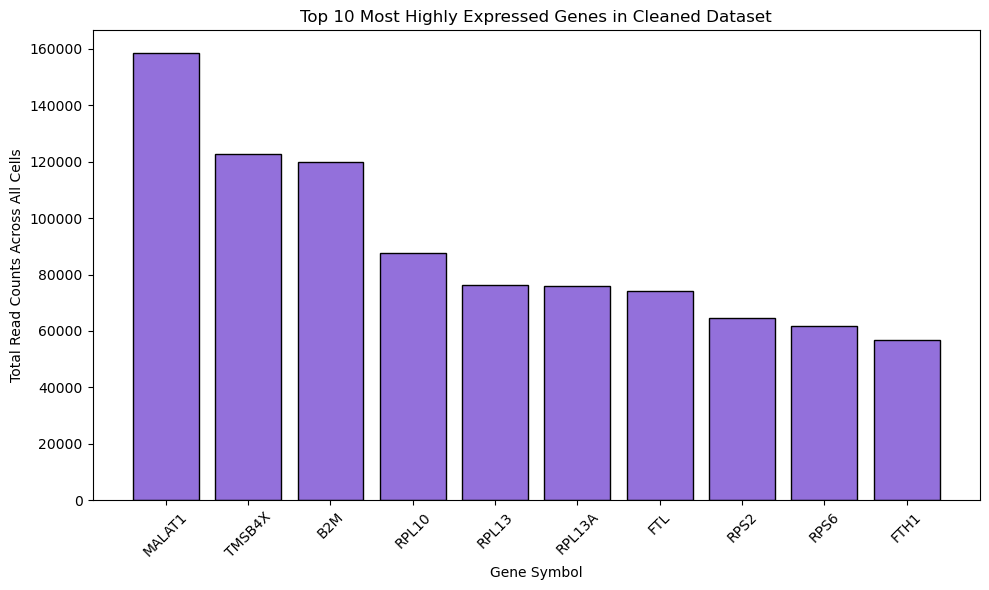

In [37]:
# Calculate total counts for each gene across all CLEANED cells (axis=0)
gene_counts = np.array(x_clean.sum(axis=0)).flatten()

# Get the indices of the top 10 highest values
# argsort sorts lowest to highest, so we slice the last 10 [:-11:-1] and reverse
top_10_indices = np.argsort(gene_counts)[:-11:-1]

# Extract the names and counts of those top 10 genes
top_10_genes = genes[top_10_indices]
top_10_counts = gene_counts[top_10_indices]

# Visualization 4: Top 10 Highly Expressed Genes
plt.figure(figsize=(10, 6))
plt.bar(top_10_genes, top_10_counts, color='mediumpurple', edgecolor='black')
plt.title('Top 10 Most Highly Expressed Genes in Cleaned Dataset')
plt.xlabel('Gene Symbol')
plt.ylabel('Total Read Counts Across All Cells')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Progress Check - #1 EDA + Inital Cleaning 

I have successfully initated the "From Scratch" Single Cell RNA seq pipeline. Bypassing black-box bioinformatics libraries, I manually laoded the 10X Genomcis Datasets into a compressed sparse row matrix using 'scipy' and 'numpy' to optimize memory architecture.
I conducted Exploratory Data Analyssi by calculating three core summary statistics: Library Size, Detected Genes, and Mitochondrial Ratio. The visulization confrim standard biological distrbution. Applying an inital cleaning mask ( removing cells with <200 genes or >5% mitochondrial content) successfully stripped the dataset of empty sequencing droplets and dead cells with ruptered membranes. The matrix is now clean and ready for normalization. 